# CLASIFICACION CON SVM Y NN

En la presente actividad se va a emplear un dataset que contiene información de características de celulares para clasificarlos en un rango de precios.

La información del *dataset* es:
* *battery_power*: Energía total que una batería puede almacenar en un tiempo medido en *mAh*
* *blue*: Indica si tiene *bluetooth* o no
* *clock_speed*: Velocidad del microprocesador
* *dual_sim*: Indica si tiene soporte dual de *sim* o no
* *fc*: Megapíxeles de la cámara frontal
* *four_g*: Indica si tiene 4G o no
* *int_memory*: Memoria interna en GB
* *m_dep*: Grosor del celular en cm
* *mobile_wt*: Peso del celular
* *n_cores*: Número de núcleos del procesador
* *pc*: Megapíxeles de la cámara principal
* *px_height*: Alto de la resolución de píxeles
* *px_width*: Ancho de resolución de píxeles
* *ram*: RAM en MB
* *sc_h*: Alto de la pantalla en cm
* *sc_w*: Ancho de la pantalla en cm
* *talk_time*: tiempo máximo que durará una sola carga de la batería
* *tres_g*: Indica si es 3G o no
* *touch_screen*: Indica si tiene pantalla táctil o no
* *wifi*: Indica si tiene wifi o no
* ***price_range***: Es la variable objetivo con valor 0 (bajo costo), 1 (costo medio), 2 (costo alto) y 3 (costo muy alto).

### IMPORTACIÓN DE LIBRERIAS A UTILIZAR

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from joblib.testing import param

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### CARGA DEL DATASET

In [2]:
data = pd.read_csv('train.csv')
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [3]:
#Tamaño del dataset
data.shape

(2000, 21)

In [4]:
#Información de las variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

# 1. ANÁLISIS DESCRIPTIVO DE DATOS


## Variables numéricas

In [5]:
#Resumen estadístico de las variables
data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


### **1.1. Escriba el código que permita crear la matriz de correlación de todas las variables numéricas:**

In [13]:
# Crear matriz de correlación
corr = data.corr()

# Mostramos la matriz de correlación
print(corr)

               battery_power      blue  clock_speed  dual_sim        fc  \
battery_power       1.000000  0.011252     0.011482 -0.041847  0.033334   
blue                0.011252  1.000000     0.021419  0.035198  0.003593   
clock_speed         0.011482  0.021419     1.000000 -0.001315 -0.000434   
dual_sim           -0.041847  0.035198    -0.001315  1.000000 -0.029123   
fc                  0.033334  0.003593    -0.000434 -0.029123  1.000000   
four_g              0.015665  0.013443    -0.043073  0.003187 -0.016560   
int_memory         -0.004004  0.041177     0.006545 -0.015679 -0.029133   
m_dep               0.034085  0.004049    -0.014364 -0.022142 -0.001791   
mobile_wt           0.001844 -0.008605     0.012350 -0.008979  0.023618   
n_cores            -0.029727  0.036161    -0.005724 -0.024658 -0.013356   
pc                  0.031441 -0.009952    -0.005245 -0.017143  0.644595   
px_height           0.014901 -0.006872    -0.014523 -0.020875 -0.009990   
px_width           -0.008

## Variables catégoricas

### **1.2. Escriba el código para su análisis y la creación de gráficos de frecuencia:**


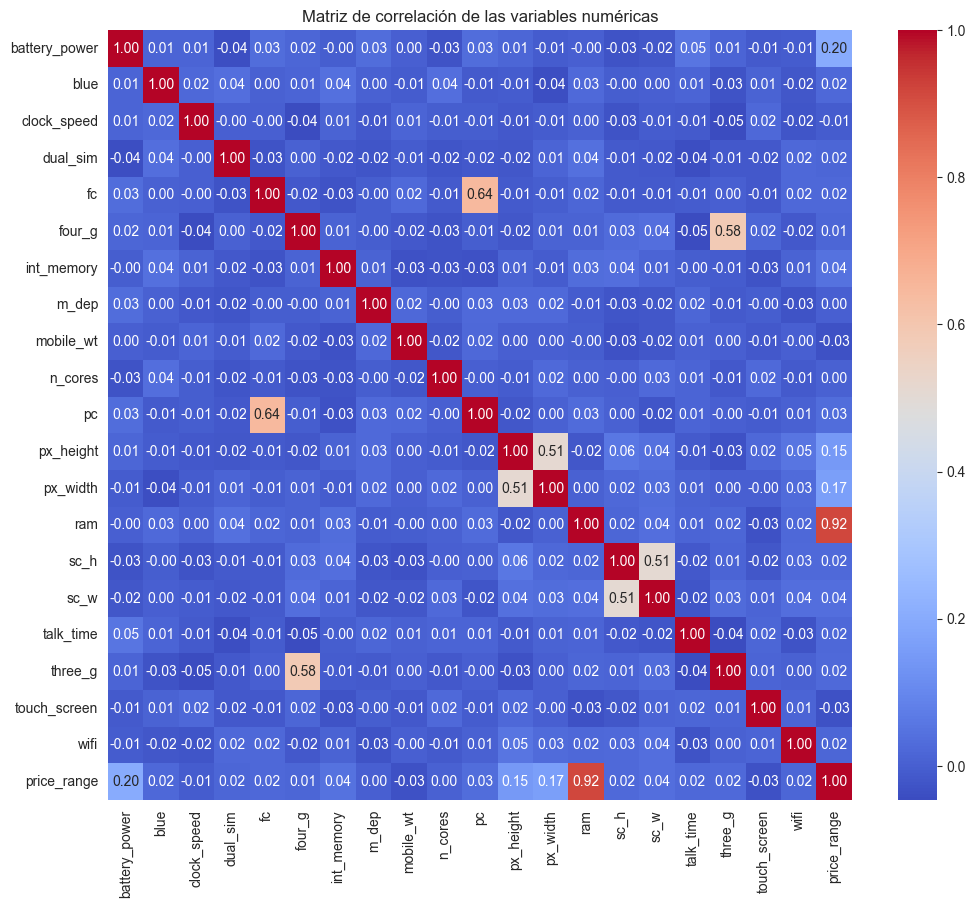

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación de las variables numéricas')
plt.show()

## Observaciones del mapa de calor
De acuerdo a lo que podemos observar en el mapa de calor, las variables que tienen una mayor correlación positiva son:
1. Ram con precio: 0.92, lo que indica que a mayor RAM, mayor precio.
2. pc con fc: 0.64, variables que indican los megapíxeles de la cámara principal y frontal.
3. four_g con three_g: 0.58, variables que indican si el celular tiene 4G o 3G.
4. sc_w con sc_h: 0.51, variables que indican el ancho y alto de la pantalla.


### **1.3. Escriba el código que permita validar si el dataset está balanceado**

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


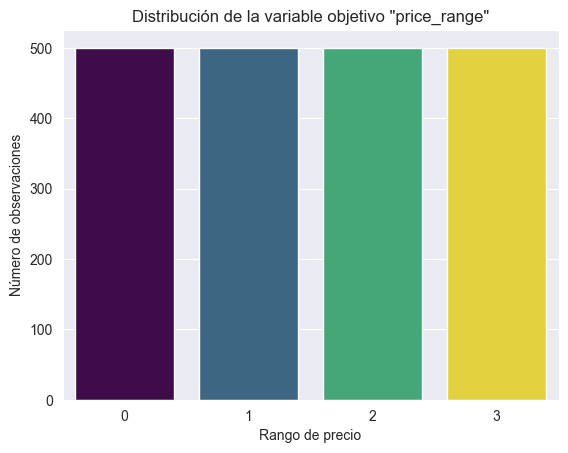

In [19]:
# Contar el número de intancias por cada clase de la variable objetivo 'price_range'
print(data['price_range'].value_counts())

# Gráfico de barras de la variable objetivo
ax = sns.countplot(x='price_range', data=data, hue='price_range', palette='viridis')
ax.legend_.remove()  # Elimina la leyenda redundante
plt.title('Distribución de la variable objetivo "price_range"')
plt.xlabel('Rango de precio')
plt.ylabel('Número de observaciones')
plt.show()

## PREPROCESAMIENTO DE DATOS

In [20]:
#Crear una copia del dataset para modificaciones
data2 = data.copy()

In [21]:
#Verificar tamaño
data2.shape

(2000, 21)

### Escriba el código que permita reescalar todos los atributos del dataset utilizando la función del StandardScaler:

In [38]:
# Creamos una copia de las características (excluyendo la variable objetivo)
X = data2.drop(columns = 'price_range')

# Inicializamos el StandardScaler
scaler = StandardScaler()

# Ajustamos y transformamos las características
X_scaled = scaler.fit_transform(X)

# Convertir el resultado a un DataFrame para mejor visualización
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)

# Añadimos la variable objetivo al DataFrame
data2_scaled = X_scaled_df.copy()
data2_scaled['price_range'] = data2['price_range'].values

# Mostramos las primeras filas del DataFrame
data2_scaled.head(10)



,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,...,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097,1
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,...,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099,2
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,...,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099,2
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,...,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099,2
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,...,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099,1
5,1.412405,-0.990050,-1.253064,0.981177,-0.301703,-1.043966,-0.553795,0.687548,0.671107,-1.539175,...,0.808917,0.931480,-0.974874,1.114266,-1.094526,-0.185077,0.559641,-1.006018,-1.014099,1
6,1.325906,-0.990050,0.217884,-1.019184,-0.071307,0.957886,-1.215274,1.034357,-0.035292,1.521249,...,-0.595280,-0.540431,1.010444,0.164641,0.512708,1.279430,0.559641,-1.006018,0.986097,3
7,1.628654,-0.990050,-1.253064,0.981177,-0.992890,-1.043966,-0.443549,1.034357,1.320993,-0.227564,...,-0.300016,-0.237254,-1.313291,0.876859,-0.635317,-1.100394,0.559641,0.994018,0.986097,0
8,0.470015,1.010051,-1.253064,-1.019184,-0.992890,-1.043966,1.155024,0.687548,0.953666,1.084046,...,-0.584011,-0.961638,-0.945367,1.114266,-1.094526,1.645557,0.559641,-1.006018,-1.014099,0
9,-1.660607,1.010051,-1.130485,0.981177,-0.532099,0.957886,-1.270397,-1.393304,-1.335064,0.209639,...,1.108689,-0.063680,-1.485727,1.589078,0.971917,0.181050,0.559641,-1.006018,-1.014099,0


# 2. Aplicación de SVM sobre los datos


In [40]:
# Separación de los datos en variables predictoras y la variable objetivo (80% train, 20% test)
X = data2.drop(columns = 'price_range')
y = data2['price_range']


# Dividir el dataset en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,
                                        random_state = 123,
                                        shuffle      = True
                                    )

### **2.1. Escriba el código que permita crear un modelo utilizando SVM con kernel lineal, el valor de C =1 y la semilla aleatoria es de 1234:**

In [41]:
# Creación del modelo SVM lineal
modeloSVM = SVC(kernel = 'linear', C = 1, random_state = 1234)
modeloSVM.fit(X_train, y_train)

SVC(C=1, kernel='linear', random_state=1234)

In [42]:
# Predicciones test
predictSVM = modeloSVM.predict(X_test)
predictSVM

array([1, 3, 3, 1, 3, 3, 1, 0, 0, 1, 0, 1, 3, 1, 1, 3, 0, 3, 2, 1, 1, 1,
       0, 3, 2, 2, 3, 2, 2, 1, 0, 1, 0, 1, 2, 3, 1, 2, 1, 1, 2, 3, 2, 1,
       1, 0, 0, 2, 2, 0, 3, 1, 2, 1, 0, 2, 0, 0, 2, 3, 1, 0, 2, 1, 2, 2,
       0, 2, 3, 1, 3, 1, 0, 2, 0, 2, 0, 1, 1, 0, 0, 0, 3, 2, 2, 1, 2, 0,
       0, 2, 2, 2, 1, 2, 3, 0, 0, 1, 0, 3, 2, 1, 3, 3, 2, 1, 3, 2, 3, 3,
       2, 3, 3, 2, 3, 3, 3, 0, 1, 3, 2, 2, 3, 0, 1, 1, 3, 2, 2, 1, 3, 0,
       3, 1, 0, 2, 2, 3, 1, 3, 2, 2, 3, 1, 3, 2, 2, 0, 0, 1, 1, 3, 2, 0,
       3, 3, 3, 0, 0, 0, 2, 0, 1, 3, 1, 1, 0, 1, 1, 0, 1, 2, 1, 1, 2, 0,
       2, 0, 2, 2, 2, 3, 2, 0, 3, 3, 1, 1, 1, 2, 2, 1, 2, 3, 0, 3, 1, 2,
       3, 1, 1, 1, 0, 3, 2, 3, 1, 3, 3, 2, 3, 2, 3, 1, 1, 0, 0, 1, 2, 1,
       0, 1, 1, 2, 2, 1, 3, 1, 2, 1, 0, 3, 3, 2, 1, 2, 2, 2, 1, 0, 0, 2,
       3, 2, 2, 1, 1, 3, 2, 3, 0, 1, 2, 2, 0, 3, 3, 0, 3, 0, 3, 0, 2, 0,
       1, 2, 2, 1, 3, 1, 0, 0, 1, 0, 3, 1, 2, 2, 3, 3, 3, 2, 3, 3, 1, 1,
       1, 2, 2, 3, 2, 2, 3, 3, 1, 2, 2, 1, 2, 1, 1,

### **2.2. Escriba el código que permita hallar la exactitud (accuracy) del modelo SVM anteriormente entrenado:**

In [44]:
predictSVM = modeloSVM.predict(X_test)
accuracySVM = accuracy_score(y_test, predictSVM)
print(f'Accuracy del modelo SVM: {accuracySVM:.2f}')

Accuracy del modelo SVM: 0.95


### **2.3. Escriba el código que permita encontrar los mejores parámetros para el modelo  SVM, con un param_grid = {'C': np.linspace(0.1, 100, 200), 'kernel': ('linear', 'rbf')**

#### Tunear hiperparámetros

In [47]:
param_grid = {'C': np.linspace(10, 50, 25), 'kernel': ('linear', 'rbf')}
grid_search = GridSearchCV(SVC(random_state=1234), param_grid, cv = 5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=1234),
             param_grid={'C': array([10.        , 11.66666667, 13.33333333, 15.        , 16.66666667,
       18.33333333, 20.        , 21.66666667, 23.33333333, 25.        ,
       26.66666667, 28.33333333, 30.        , 31.66666667, 33.33333333,
       35.        , 36.66666667, 38.33333333, 40.        , 41.66666667,
       43.33333333, 45.        , 46.66666667, 48.33333333, 50.        ]),
                         'kernel': ('linear', 'rbf')},
             scoring='accuracy')

### **2.4. Escriba el código que permita conocer los mejores parámetros encontrados en el ítem anterior**

In [48]:
print('Mejores parámetros encontrados: ', grid_search.best_params_)

Mejores parámetros encontrados:  {'C': np.float64(10.0), 'kernel': 'linear'}


### **2.5. Escriba el código que permita hallar la exactitud del modelo de SVM aplicando los mejores parámetros**

In [51]:
# Accuracy de test del modelo
# ==============================================================================
best_model = grid_search.best_estimator_
accuracy = accuracy_score(y_test, best_model.predict(X_test))
print(f'Exactitud del modelo SVM con los mejores parámetros: {accuracy : .2f}')

Exactitud del modelo SVM con los mejores parámetros:  0.95


### **2.6. Escriba el código que permita hallar la las métricas del modelo entrenado en el ítem anterior. Utilice la función classification_report**

In [53]:
print('Reporte de clasificación del modelo SVM:')
print(classification_report(y_test, best_model.predict(X_test)))

Reporte de clasificación del modelo SVM:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96        87
           1       0.93      0.96      0.95       100
           2       0.95      0.93      0.94       116
           3       0.94      0.97      0.95        97

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



# 3. REDES NEURONALES

### **3.1. Escriba el código que permita entrenar un perceptrón multicapa con 3 capas ocultas con 200, 100 y 50 neuronas respectivamente en cada capa. Función de activación 'Relu' y random_state=1**

In [65]:
X_nn = data2_scaled.drop(columns = 'price_range')
y_nn = data2_scaled['price_range']


# Dividir el dataset en entrenamiento y prueba (80% train, 20% test)
X_nn_train, X_nn_test, y_nn_train, y_nn_test = train_test_split(X_nn, y_nn, train_size = 0.8, random_state = 123, shuffle = True)

# Entrenar el perceptrón multicapa con 3 capas ocultas con 200, 100 y 50 neuronas, activación 'relu' y random_state=1
mlp = MLPClassifier(hidden_layer_sizes=(200, 100, 50),
                    activation='relu',
                    random_state=1,
                    max_iter=10000
                    )

mlp.fit(X_nn_train, y_nn_train)

MLPClassifier(hidden_layer_sizes=(200, 100, 50), max_iter=10000, random_state=1)

### **3.2. Escriba el código que permita hallar la exactitud del modelo de redes neuronales anteriormente entrenado:**

In [63]:
# Prediccion en el conjunto de test
nn_predict = mlp.predict(X_nn_test)

### **3.3. Escriba el código que permita hallar la las métricas del modelo entrenado en el ítem anterior. Utilice la función classification_report**

In [64]:
accuracy_nn = accuracy_score(y_nn_test, nn_predict)
print(f'Exactitud del modelo de redes neuronales: {accuracy_nn:.2f}')

print('Reporte de clasificación del modelo de redes neuronales:')
print(classification_report(y_nn_test, nn_predict))

Exactitud del modelo de redes neuronales: 0.93
Reporte de clasificación del modelo de redes neuronales:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        87
           1       0.93      0.91      0.92       100
           2       0.92      0.91      0.91       116
           3       0.93      0.93      0.93        97

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.92       400



### 4. **Conclusiones**